# Data Understanding - Walmart Sales Analysis

This notebook focuses on understanding the Walmart sales dataset through exploratory data analysis. We'll examine the data structure, types, missing values, and basic statistics to gain insights before proceeding with deeper analysis.

## Import Required Libraries

Import essential libraries for data manipulation, analysis, and visualization.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## Load the Dataset

Load the Walmart sales dataset from the raw data directory.

In [2]:
# Load the dataset
data_path = '../data/raw/Walmart.csv'
df = pd.read_csv(data_path)

print(f"Dataset loaded successfully from: {data_path}")
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully from: ../data/raw/Walmart.csv
Dataset shape: (6435, 8)
Number of rows: 6,435
Number of columns: 8


## Display Dataset Overview

Examine the first and last few rows of the dataset to understand its structure and content.

In [3]:
# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

print("\n" + "="*50 + "\n")

# Display last 5 rows
print("Last 5 rows of the dataset:")
display(df.tail())

print("\n" + "="*50 + "\n")

# Display column names
print("Column names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

First 5 rows of the dataset:


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106




Last 5 rows of the dataset:


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667
6434,45,26-10-2012,760281.43,0,58.85,3.882,192.308899,8.667




Column names:
1. Store
2. Date
3. Weekly_Sales
4. Holiday_Flag
5. Temperature
6. Fuel_Price
7. CPI
8. Unemployment


## Explore Data Types and Missing Values

Examine the data types of each column and check for missing values.

In [4]:
# Display data types and non-null counts
print("Data types and missing values information:")
print("-" * 50)
df.info()

print("\n" + "="*50 + "\n")

# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

print("Missing values summary:")
print("-" * 30)
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
})
display(missing_summary[missing_summary['Missing Count'] > 0])

if missing_values.sum() == 0:
    print("✅ No missing values found in the dataset!")
else:
    print(f"⚠️  Found {missing_values.sum()} missing values across {len(missing_summary[missing_summary['Missing Count'] > 0])} columns")

Data types and missing values information:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


Missing values summary:
------------------------------


,Missing Count,Missing Percentage


✅ No missing values found in the dataset!


## Generate Descriptive Statistics

Calculate basic statistical measures for numerical columns to understand the data distribution.

In [5]:
# Descriptive statistics for numerical columns
print("Descriptive statistics for numerical columns:")
print("-" * 50)
display(df.describe())

print("\n" + "="*50 + "\n")

# Descriptive statistics for categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
if len(categorical_cols) > 0:
    print("Descriptive statistics for categorical columns:")
    print("-" * 50)
    display(df[categorical_cols].describe())

    print("\nUnique values in categorical columns:")
    for col in categorical_cols:
        unique_vals = df[col].unique()
        print(f"\n{col}: {len(unique_vals)} unique values")
        if len(unique_vals) <= 10:
            print(f"Values: {unique_vals}")
        else:
            print(f"First 10 values: {unique_vals[:10]}")
else:
    print("No categorical columns found in the dataset.")

Descriptive statistics for numerical columns:
--------------------------------------------------


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000




Descriptive statistics for categorical columns:
--------------------------------------------------


C:\Users\AGYAL\AppData\Local\Temp\ipykernel_14612\1287863938.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


,Date
count,6435
unique,143
top,05-02-2010
freq,45



Unique values in categorical columns:

Date: 143 unique values
First 10 values: <StringArray>
['05-02-2010', '12-02-2010', '19-02-2010', '26-02-2010', '05-03-2010',
 '12-03-2010', '19-03-2010', '26-03-2010', '02-04-2010', '09-04-2010']
Length: 10, dtype: str


## Visualize Data Distribution

Create visualizations to understand the distribution of numerical features.

Found 7 numerical columns: ['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


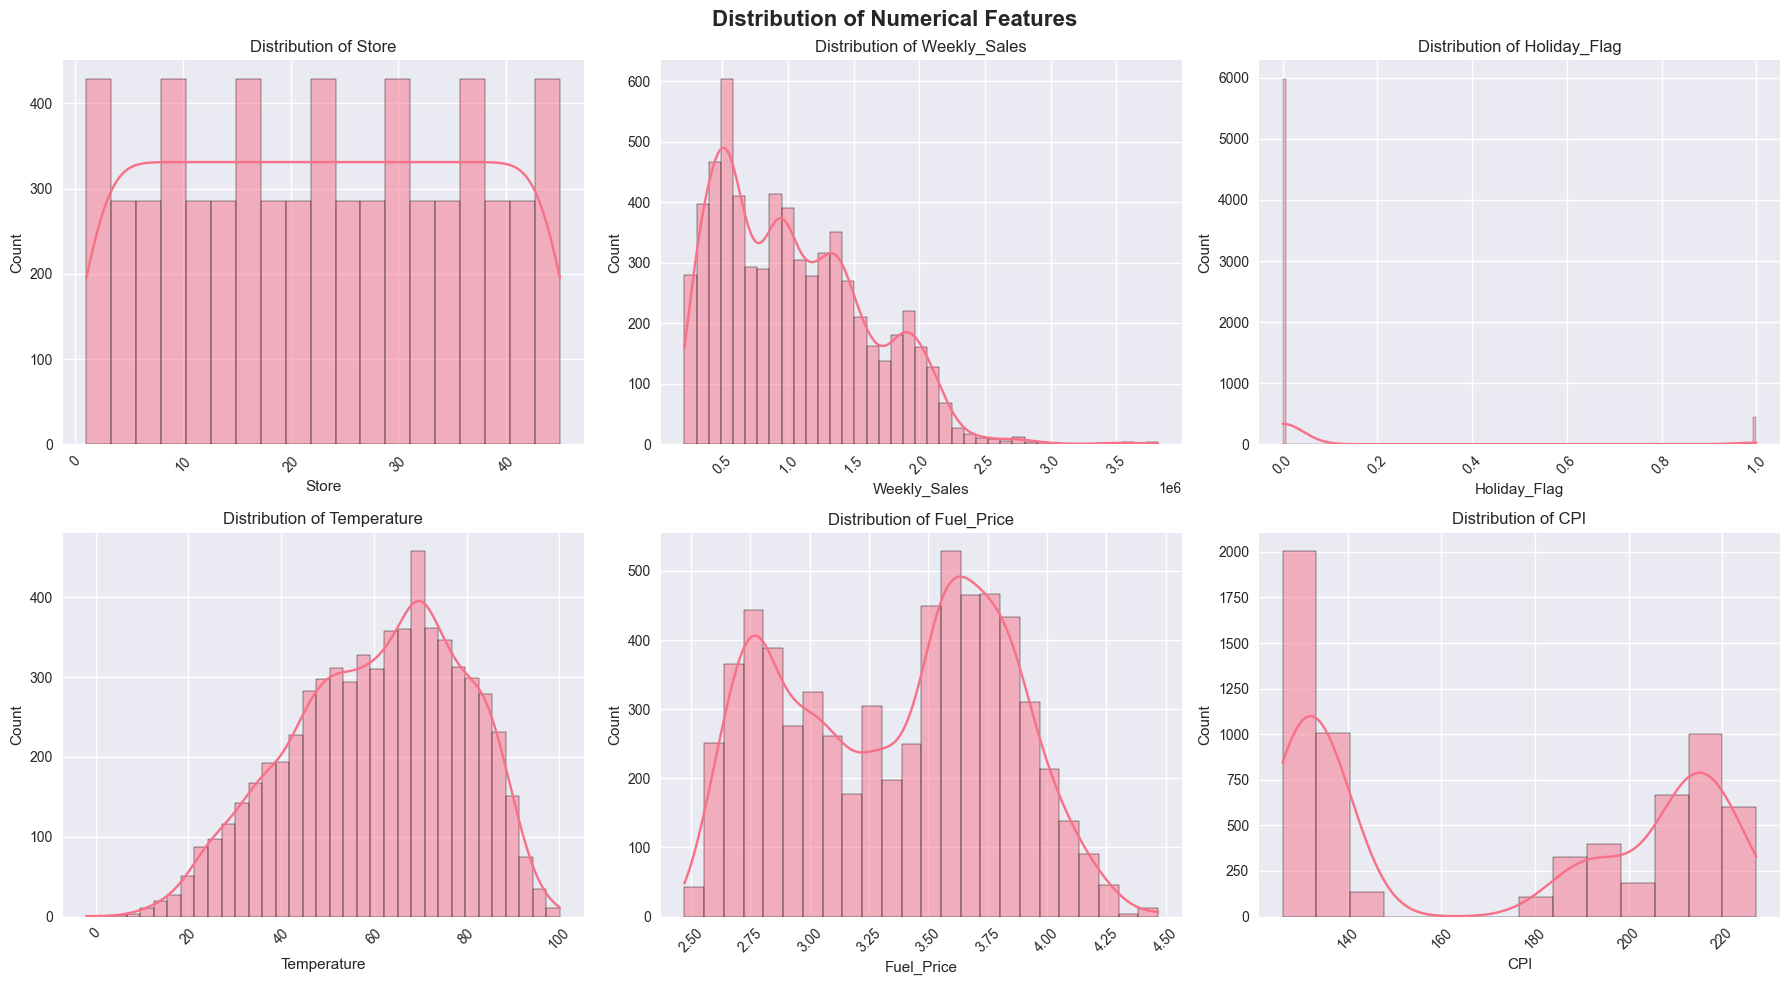

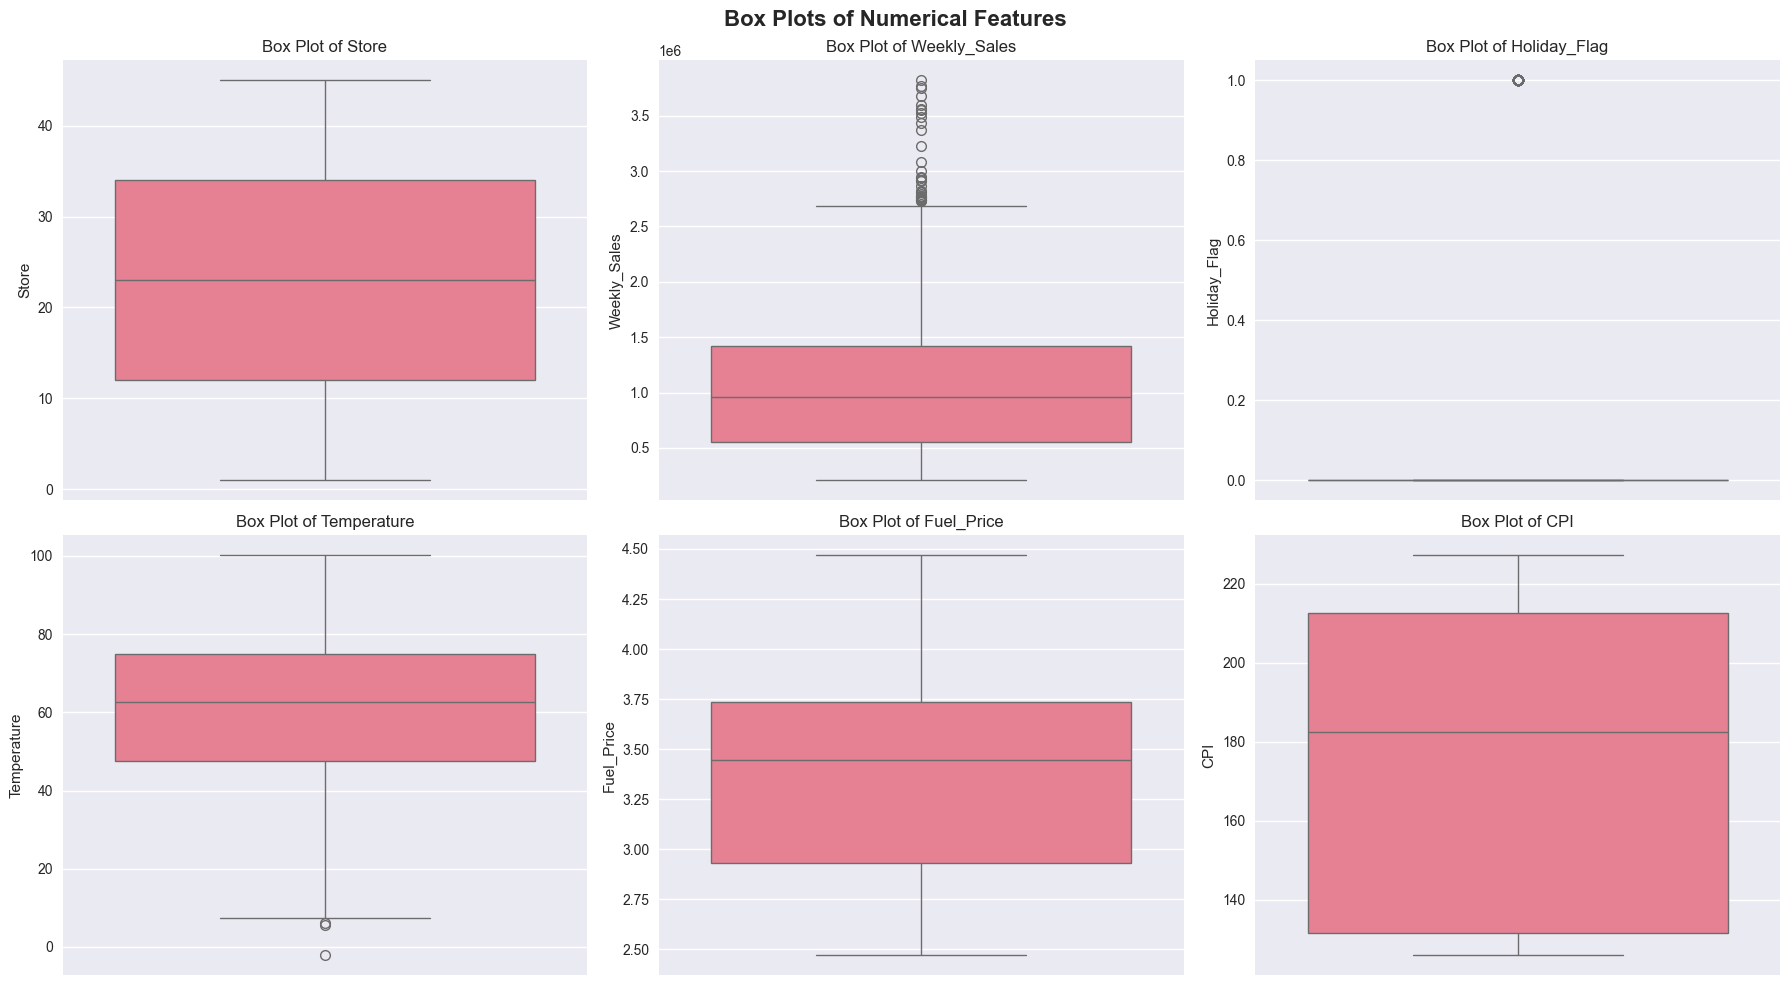

In [9]:
# Get numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns

print(f"Found {len(numerical_cols)} numerical columns: {list(numerical_cols)}")

# Create subplots for histograms
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.histplot(data=df, x=col, ax=axes[i], kde=True)
        axes[i].set_title(f'Distribution of {col}')
        axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

# Box plots for numerical columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Box Plots of Numerical Features', fontsize=16, fontweight='bold')

axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.boxplot(data=df, y=col, ax=axes[i])
        axes[i].set_title(f'Box Plot of {col}')

# Hide empty subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## Analyze Correlations

Compute correlation matrices and create heatmaps to identify relationships between numerical variables.

Correlation Matrix:
--------------------


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store,1.000,-0.335,-0.000,-0.023,0.060,-0.209,0.224
Weekly_Sales,-0.335,1.000,0.037,-0.064,0.009,-0.073,-0.106
Holiday_Flag,-0.000,0.037,1.000,-0.155,-0.078,-0.002,0.011
Temperature,-0.023,-0.064,-0.155,1.000,0.145,0.177,0.101
Fuel_Price,0.060,0.009,-0.078,0.145,1.000,-0.171,-0.035
CPI,-0.209,-0.073,-0.002,0.177,-0.171,1.000,-0.302
Unemployment,0.224,-0.106,0.011,0.101,-0.035,-0.302,1.000


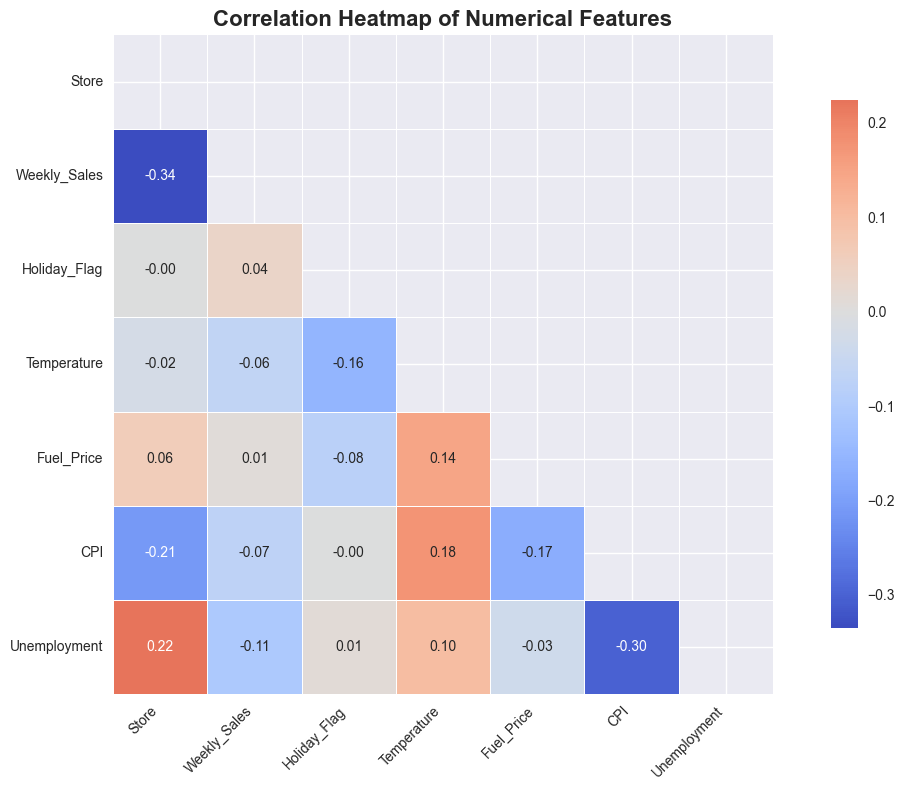



No strong correlations found between numerical variables.


In [10]:
# Calculate correlation matrix
correlation_matrix = df[numerical_cols].corr()

print("Correlation Matrix:")
print("-" * 20)
display(correlation_matrix.round(3))

print("\n" + "="*50 + "\n")

# Create heatmap
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            mask=mask, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

# Identify strong correlations (|correlation| > 0.5)
strong_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            strong_correlations.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })

if strong_correlations:
    print("Strong correlations found (|correlation| > 0.5):")
    strong_corr_df = pd.DataFrame(strong_correlations)
    display(strong_corr_df.sort_values('Correlation', key=abs, ascending=False))
else:
    print("No strong correlations found between numerical variables.")

## Summary and Next Steps

### Key Findings:
- Dataset shape and basic information
- Data types and missing values status
- Statistical summary of numerical features
- Distribution patterns from visualizations
- Correlation relationships between variables

### Next Steps:
1. Data preprocessing and cleaning
2. Feature engineering
3. Time series analysis
4. Statistical analysis and pattern discovery
5. Advanced visualizations and insights

This completes the initial data understanding phase. The dataset is ready for further analysis in subsequent notebooks.